# Beslisboom maken waarbij je zelf de features kunt kiezen

In dit notebook trainen we op basis van de synthetische data van Lighthouse een eenvoudige beslisboom. Het notebook geeft suggesties voor features, maar de gebruiker kan zelf een lijstje opgeven van features die je wil opnemen. Met de hyperparameter max_depth kan je bepalen hoe groot de boom wordt.

Doel is voor: kijken wat het effect is als je bepaalde features wel of niet opneemt.

In [25]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import re
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
data_path = Path('synth_data_scored.csv')
df = pd.read_csv(data_path)
df.columns = df.columns.str.strip()  # remove accidental whitespace from column names
target_column = 'Ja'
df.drop(columns=['Nee'], inplace=True)


print('Data shape:', df.shape)
print('Target column exists:', target_column in df.columns)
print('Target summary:')
print(df[target_column].describe())
print('First rows of target:')
print(df[target_column].head())

Data shape: (4460, 316)
Target column exists: True
Target summary:
count    4459.000000
mean        0.610461
std         0.086473
min         0.270290
25%         0.557368
50%         0.620808
75%         0.672384
max         0.805376
Name: Ja, dtype: float64
First rows of target:
0    0.600234
1    0.748566
2    0.781536
3    0.613350
4    0.688989
Name: Ja, dtype: float64


## Feature impact candidates

Overzicht van de features die een sterke relatie hebben met de target - kan overgeslagen worden

In [10]:
numeric_features = df.select_dtypes(include=[np.number]).columns.drop(target_column)
correlations = df[numeric_features].corrwith(df[target_column]).abs().sort_values(ascending=False)

print('Top numeric candidate features by absolute Pearson correlation to Ja:')
impact_df = correlations.head(20).rename('abs_corr').to_frame()
display(impact_df)

print('\nA higher absolute correlation suggests a stronger linear relationship with the target.\n')

feature_counts = df[numeric_features].nunique().loc[impact_df.index]
feature_impact = impact_df.assign(unique_values=feature_counts)
print('Top candidate features with distinct value counts:')
display(feature_impact)

Top numeric candidate features by absolute Pearson correlation to Ja:


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,abs_corr
relatie_overig_actueel_vorm__kostendeler,0.443404
contacten_onderwerp_no_show,0.333553
relatie_overig_kostendeler,0.332118
persoon_leeftijd_bij_onderzoek,0.318643
relatie_overig_historie_vorm__kostendeler,0.309525
pla_hist_pla_categorie_doelstelling_16,0.308362
afspraak_resultaat_ingevuld_uniek,0.297079
contacten_onderwerp_overleg_met_inkomen,0.281720
pla_historie_ontwikkeling,0.271602
instrument_ladder_huidig_activering,0.258022



A higher absolute correlation suggests a stronger linear relationship with the target.

Top candidate features with distinct value counts:


,abs_corr,unique_values
relatie_overig_actueel_vorm__kostendeler,0.443404,5
contacten_onderwerp_no_show,0.333553,6
relatie_overig_kostendeler,0.332118,2
persoon_leeftijd_bij_onderzoek,0.318643,49
relatie_overig_historie_vorm__kostendeler,0.309525,7
pla_hist_pla_categorie_doelstelling_16,0.308362,4
afspraak_resultaat_ingevuld_uniek,0.297079,10
contacten_onderwerp_overleg_met_inkomen,0.281720,7
pla_historie_ontwikkeling,0.271602,2
instrument_ladder_huidig_activering,0.258022,4


## Feature selection

Bepaal zelf welke features je wil opnemen door de namen op te voeren. Als je bv een tikfout maakt krijg je een foutmelding. Je kunt zo veel of weinig features opnemen als je wil.

In [26]:
selected_features = [
    'persoon_geslacht_vrouw',
    'relatie_kind_huidige_aantal',
   # 'relatie_partner_huidige_partner___partner__gehuwd_',
   # 'adres_aantal_brp_adres',
   # 'persoon_leeftijd_bij_onderzoek',
   # 'belemmering_hist_verslavingsproblematiek',
    'belemmering_financiele_problemen',
    'persoonlijke_eigenschappen_spreektaal_anders'
]

missing = [c for c in selected_features if c not in df.columns]
if missing:
    raise ValueError(f'Missing selected features in the dataset: {missing}')

X = df[selected_features].copy()
y = df[target_column].copy()

print('Using', len(selected_features), 'features:')
for feature in selected_features:
    print('-', feature)

Using 4 features:
- persoon_geslacht_vrouw
- relatie_kind_huidige_aantal
- belemmering_financiele_problemen
- persoonlijke_eigenschappen_spreektaal_anders


## Train / test split, scaling and model training

Het daadwerkelijk trainen van het model inclusief de voorbereiding van de dataset bestaande uit de gekozen features

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

max_depth = 3  # set tree depth here before training
model = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
# model.fit(X_train_scaled, y_train)
model.fit(X_train, y_train)


print(f'Model trained successfully with max_depth={max_depth}')
print('Training set size:', X_train.shape[0])
print('Test set size:', X_test.shape[0])

Model trained successfully with max_depth=3
Training set size: 3345
Test set size: 1115


Inferentie - testen hoe goed het model haar werk doet - kan overgeslagen worden

In [23]:
y_pred = model.predict(X_test)
#mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('Evaluation on test set:')
print(f'  MAE : {mae:.5f}')
print(f'  RMSE: {rmse:.5f}')
print(f'  R2  : {r2:.5f}')



ValueError: Input contains NaN.

## Decision tree visualization

Laten zien hoe de beslisboom eruit ziet om te bekijken wat die doet met de features die je hebt opgegeven.

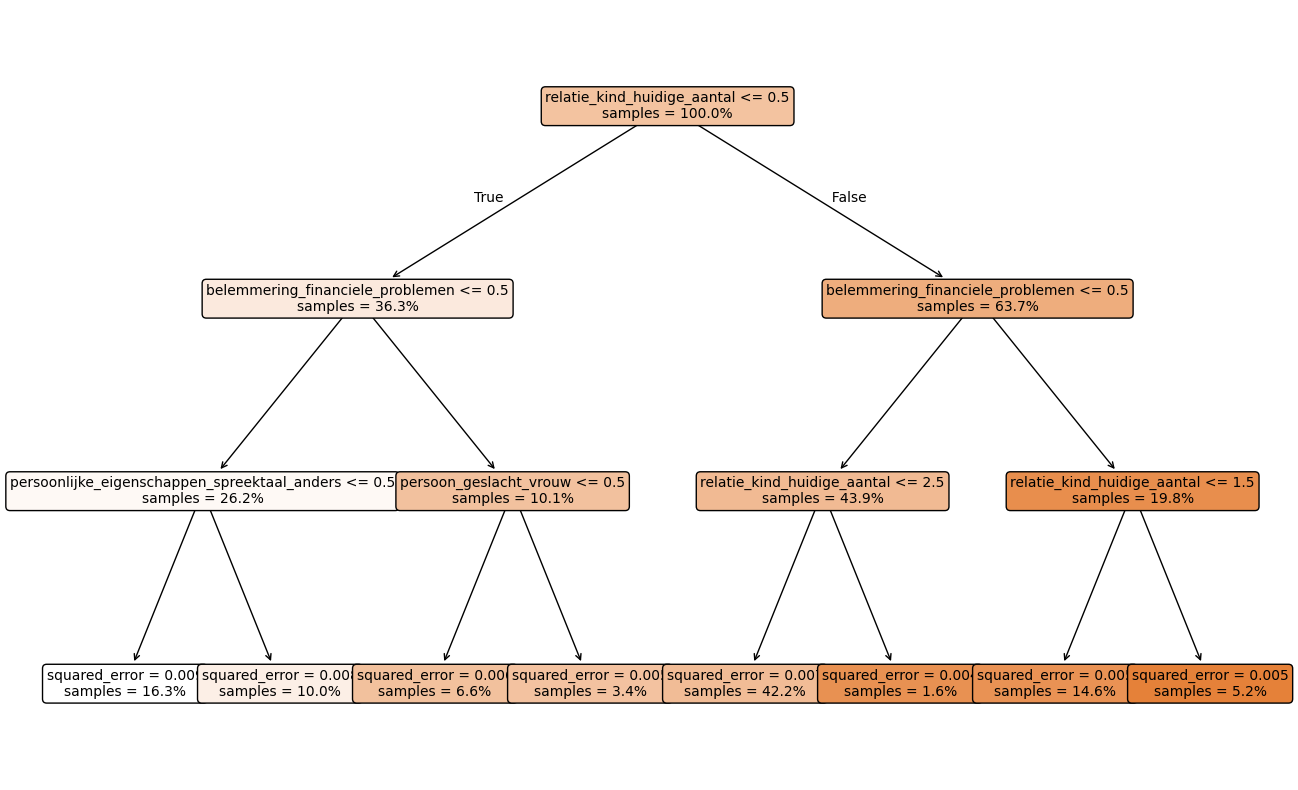

In [39]:
#plt.figure(figsize=(16, 10))
fig, ax = plt.subplots(figsize=(16,10))

plot_tree(
    model,
    ax=ax,
    feature_names=selected_features,
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    precision=3
)
def replace_text(obj):
    if type(obj) == matplotlib.text.Annotation:
        txt = obj.get_text()
        txt = re.sub("\nvalue[^$]*","",txt)
        txt = re.sub("\nsquared_error[^$]*samples","\nsamples",txt)
        obj.set_text(txt)
    return obj

# fig.title('Decision Tree Visualization')
ax.properties()['children'] = [replace_text(i) for i in ax.properties()['children']]
fig.show()

## Feature importances and tree structure

Analyse van de gebruikte features, alleen gebruiken als je het interessant vindt

,feature,importance
1,relatie_kind_huidige_aantal,0.450284
5,belemmering_financiele_problemen,0.272819
3,adres_aantal_brp_adres,0.194473
0,persoon_geslacht_vrouw,0.025561
4,belemmering_hist_verslavingsproblematiek,0.021570
6,persoonlijke_eigenschappen_spreektaal_anders,0.020375
2,relatie_partner_huidige_partner___partner__geh...,0.014918


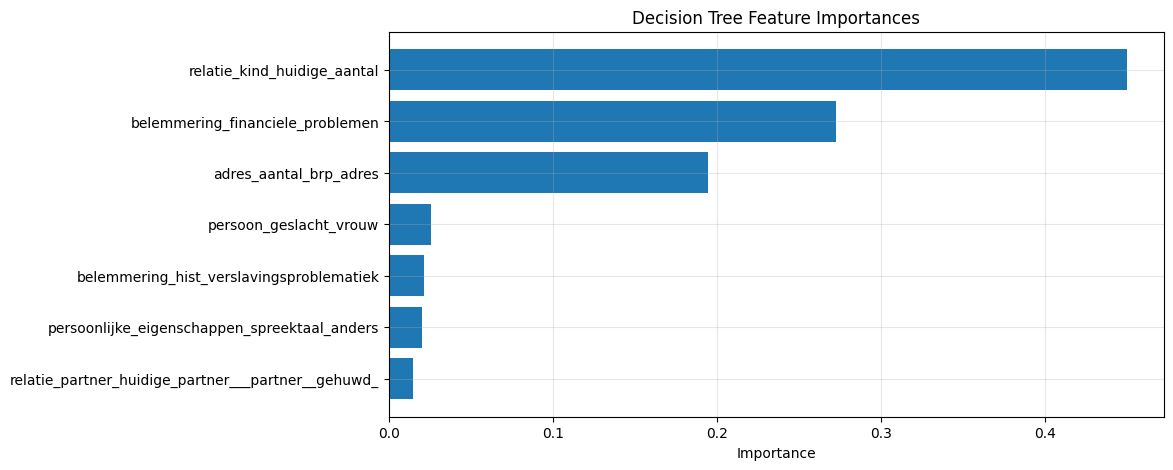

Tree structure (first levels):
|--- relatie_kind_huidige_aantal <= -0.46
|   |--- belemmering_financiele_problemen <= 0.41
|   |   |--- adres_aantal_brp_adres <= -0.94
|   |   |   |--- persoonlijke_eigenschappen_spreektaal_anders <= 0.05
|   |   |   |   |--- persoon_geslacht_vrouw <= 0.03
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- persoon_geslacht_vrouw >  0.03
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- persoonlijke_eigenschappen_spreektaal_anders >  0.05
|   |   |   |   |--- belemmering_hist_verslavingsproblematiek <= 1.88
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- belemmering_hist_verslavingsproblematiek >  1.88
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |--- adres_aantal_brp_adres >  -0.94
|   |   |   |--- persoon_geslacht_vrouw <= 0.03
|   |   |   |   |--- persoonlijke_eigenschappen_spreektaal_anders <= 0.05
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   

In [ ]:
import pandas as pd
importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title('Decision Tree Feature Importances')
plt.xlabel('Importance')
plt.grid(True, alpha=0.3)
plt.show()